## 1) 데이터 전처리(Data Preprocessing)
* 필요성 : ML 알고리즘은 어떤 데이터를 입력하는지에 따라 결과가 크게 바뀔 수 있음(Garbage In, Garbage Out)
* 사이킷런의 ML 알고리즘 적용 전에 처리해야 할 사항
  * 결손값(NaN, Null)을 허용하지 않음 -> 고정된 다른 값으로 변환해야 함
    * Null 값이 얼마 되지 않는 경우 : feature의 평균값 등으로 간단 대체 가능
    * Null 값이 대부분인 경우 : 해당 feature은 drop 하는 것이 좋음
    * Null 값이 일정 수준 이상(기준은 없음)인 경우 : 해당 feature가 중요도가 높다면 단순 평균 등으로 대체한다면 예측 왜곡 심할 수 있음. 더 정밀한 대체값 선정 필요
  * 문자열 값을 입력값으로 허용하지 않음 -> 모든 문자열 값은 인코딩 되어 숫자형으로 변환해야 함
    * 카테고리형 feature : 코드 값
    * 텍스트형 feature : 피처 벡터화(feature vectorization) 등으로 벡터화하거나 불필요한 feature일 경우 삭제(주민번호, 아이디 등은 단순히 데이터 row를 식별하는 용도이므로 중요 요소 아님. 알고리즘 복합하게 할 뿐)

## 2) 데이터 인코딩
* 대표적 ML 데이터 인코딩 방식 : 레이블 인코딩(Label Encoding), 원-핫 인코딩(One-Hot Encoding)

### (1) 레이블 인코딩
* 카테고리 피처를 코드형 숫자값으로 변환하는 것
* '01', '02'도 문자열이므로 1, 2와 같은 숫자형으로 변환해야 함
* 사이킷런의 LabelEncoder 클래스로 구현 -> fit(), transform() 호출해 레이블 인코딩 진행
* 데이터 수가 많아 어떤 문자열이 어떤 숫자로 인코딩 되었는지 확인 힘들 경우 LabelEncoder 객체의 **classes_ 속성** 이용
* 인코딩 값을 다시 디코딩하려면 inverse_transform() 사용
* 일괄적인 숫자값으로 변환되며, 숫자값의 크고 작음, 순서나 중요도의 특성으로 작용할 수 있음 -> 특정 ML 알고리즘에서 가중치가 더 부여되는 등 문제를 일으킬 수 있음 -> 회귀 등에 쓰이지 않음. 트리 계열 ML 알고리즘은 괜찮음

### (2) 원-핫 인코딩
* 행 형태로 된 피처 고유 값을 열 형태로 차원 변환한 뒤, 고유 값에 해당하는 칼럼에만 1을 표시하고 나머지는 0으로 표시
* 피처 값의 유형에 따라 새로운 피처를 추가해 고유 값에 해당하는 칼럼에만 1을 표시. 나머지는 0 표시(여러 개의 속성 중 단 한 개의 속성만 1로 표시)
* 사이킷런에서 OneHotEncoder 클래스 사용
  * 변환 전 모든 문자열이 숫자형 값으로 변환되어야 함
  * 변환 전 입력값으로 2차원 데이터가 필요함
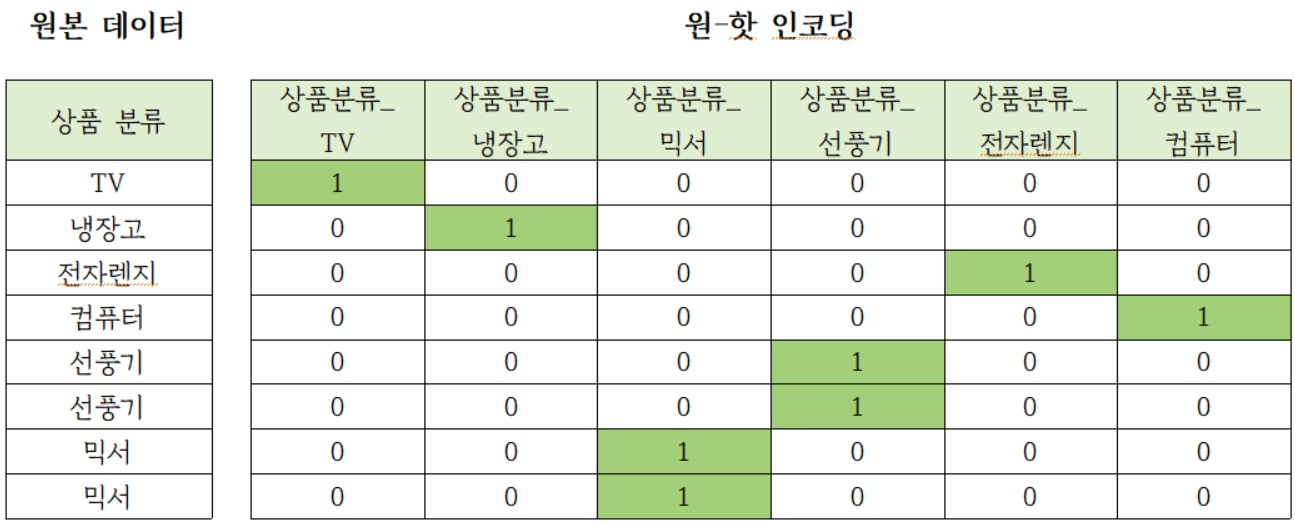
* Pandas의 get_dummies() : 원-핫인코딩을 쉽게 지원하는 API. 문자열 카테고리 값을 숫자형으로 변환할 필요 없이 바로 변환 가능

In [3]:
### Label Encoding : LabelEncoder Class

from sklearn.preprocessing import LabelEncoder

items = ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']
encoder = LabelEncoder() #객체 생성
encoder.fit(items)
labels = encoder.transform(items)
print('인코딩 변환값 : ', labels)
print('인코딩 클래스 : ', encoder.classes_)
print('디코딩 원본값 : ', encoder.inverse_transform([4, 5, 2, 0, 1, 1, 3, 3]))

인코딩 변환값 :  [0 1 4 5 3 3 2 2]
인코딩 클래스 :  ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']
디코딩 원본값 :  ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


In [6]:
### One-Hot Encoding : OneHotEncoder Class

from sklearn.preprocessing import OneHotEncoder

items = ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

#숫자값으로 변환해야 하므로 LabelEncoder로 변환
encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)

#2차원 데이터로 변환
labels = labels.reshape(-1, 1)

#원핫인코딩 적용
oh_encoder = OneHotEncoder()
oh_encoder.fit(labels)
oh_labels = oh_encoder.transform(labels)
print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


In [7]:
### One Hot Encoding : Pandas

import pandas as pd

df = pd.DataFrame({'items':['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']})
pd.get_dummies(df)

,items_TV,items_냉장고,items_믹서,items_선풍기,items_전자레인지,items_컴퓨터
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,0,0,1,0
3,0,0,0,0,0,1
4,0,0,0,1,0,0
5,0,0,0,1,0,0
6,0,0,1,0,0,0
7,0,0,1,0,0,0


## 3) 피처 스케일링과 정규화
* 피처 스케일링(Feature Scaling) : 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업. 표준화와 정규화가 대표적
* 표준화(Standardization) : 데이터 피처 각각이 평균이 0이고 분산이 1인 가우시안 정규 분포를 가진 값으로 변환하는 것
  * 표준화를 통해 변환될 피처 x의 새로운 i 번째 데이터는 (원래 값에서 피처 x의 평균을 뺀 값)을 (피처 x의 표준편차)로 나눈 값
  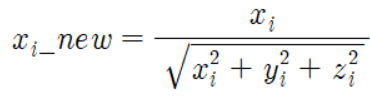
* 정규화(Normalization) : 서로 다른 피처의 크기를 통일하기 위해 크기를 변환해주는 것
  * 동일한 크기 단위로 비교하기 위해 값을 모두 0~1 값으로 변환 -> 개별 데이터의 크기를 모두 똑같은 단위로 변경
  * 새로운 데이터는 (원래 값에서 피처 x의 최솟값을 뺀 값)을 (피처 x의 최댓값외 최솟값의 차이)로 나눈 값
  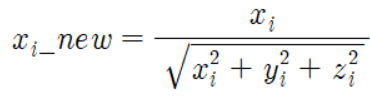
  * 사이킷런에서 Normalizer 모듈을 사용(일반적 정규화와 차이 약간 있음)
    * 선형대수 정규화 개념 적용 : 개별 벡터의 크기를 맞추기 위해 변환('벡터 정규화')
    * 개별 벡터를 모든 피처 벡터의 크기로 나눠줌
    * 새로운 데이터는 (원래 값)에서 (모든 벡터의 i 번째 해당하는 크기를 합한 값)으로 나눔
    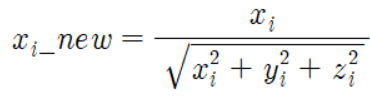
* 책에서는 '피처 스케일링' = 일반적 의미의 표준화&정규화 / '벡터 정규화' = 선형대수 개념의 정규화 로 지징

### (1) StandardScaler
* 표준화를 쉽게 지원하는 클래스 -> 개별 피처를 평균이 0이고 분산이 1이 되도록 함
* 사이킷런의 RBF 커널을 이용하는 서포트 벡터 머신(Support Vector Machine), 선형회귀(Linear Regression), 로지스틱 회귀(Logistic Regression)은 데이터가 가우시안 분포를 가지고 있다고 가정하고 구현됨 -> 표준화 한 뒤 적용해야 함

In [3]:
# 표준화 이전의 피처들의 평균&분산 값
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
iris_data = iris.data
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)

print('피처들의 평균 값')
print(iris_df.mean())
print('\n피처들의 분산 값')
print(iris_df.var())

피처들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

피처들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [4]:
# StandardScaler로 피처를 한 번에 표준화 변환하기

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() #StandardScaler 객체 생성
scaler.fit(iris_df) #StandardScaler로 데이터 세트 변환. fit() & trnasform() 호출
iris_scaled = scaler.transform(iris_df)

iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names) #transform() 시 스케일 변환된 데이터가 Numpy 배열로 반환되므로 이를 다시 DataFrame으로 변환
print('피처들의 평균 값')
print(iris_df_scaled.mean())
print('\n피처들의 분산 값')
print(iris_df_scaled.var())

피처들의 평균 값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

피처들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


### (2) MinMaxScaler
* 데이터값을 0과 1사이의 범위값으로 변환. 음수값이 있으면 -1에서 1값으로 변환
* 데이터 분포가 가우시간 분포가 아닐 경우 Min, Max Scale을 적용해볼 수 있음

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() #객체 생성
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('피처들의 최소값')
print(iris_df_scaled.min())
print('\n피처들의 최대값')
print(iris_df_scaled.max())

피처들의 최소값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

피처들의 최대값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


## 4) 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점
* Scaler 객체 이용해 데이터 스케일링 변환 시 fit(), transform(), fit_transform() 메소드 이용
  * fit() : 데이터 변환을 위한 기준 정보 설정(예; : 데이터셋의 최대/최소값 설정 등)
  * transform() : 설정된 정보를 이용해 데이터 변환
  * fit_transform() : 두 메소드를 한 번에 적용
* 학습 데이터로 fit()이 적용된 스케일링 기준 정보를 그대로 테스트 데이터에 적용해야 함
  * 테스트 데이터 셋으로는 다시 fit() 수행X -> 학습 데이터셋으로 fit() 수행한 결과로 transform() 변환 적용해야 함
  * 다시 새로운 스케일링 기준 정보를 만들면, 학습 데이터와 테스트 데이터의 스케일링 기준 정보가 서로 달라짐. 올바른 예측 결과 도출 X
* 가능한 한, 전체 데이터의 스케일링 변환을 적용한 뒤, 학습과 테스트 데이터로 분리. 그것이 여의치 않다면 테스트 데이터 변환 시에는 fit()이나 fit_transform()을 적용하지 않고 학습 데이터로 이미 fit()된 Scaler 객체를 이용해 transform으로 변환할 것
* 이 주의사항은 사이킷런 기반의 PCA 등의 차원 축소 변환, 텍스트의 피처 벡터화 변환에도 동일 적용됨

In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

train_array = np.arange(0, 11).reshape(-1, 1)
test_array = np.arange(0, 6).reshape(-1, 1)

scaler = MinMaxScaler()
scaler.fit(train_array)
train_scaled = scaler.transform(train_array)
print('원본 train_array 데이터 : ', np.round(train_array.reshape(-1), 2))
print('Scale 된 trian_array 데이터 : ', np.round(train_scaled.reshape(-1), 2))

test_scaled = scaler.transform(test_array)
print('\n원본 test_array 데이터 : ', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터 : ', np.round(test_scaled.reshape(-1), 2))

원본 train_array 데이터 :  [ 0  1  2  3  4  5  6  7  8  9 10]
Scale 된 trian_array 데이터 :  [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

원본 test_array 데이터 :  [0 1 2 3 4 5]
Scale된 test_array 데이터 :  [0.  0.1 0.2 0.3 0.4 0.5]
